# King County House Price Prediction

**Dataset:** House Sales in King County, USA <br>
**Project Objective:** To build a distributed machine learning pipeline using Apache Spark to predict real estate prices in King County based on structural, locational, and historical attributes.

## 1. Spark Initialization and Data Loading

In [ ]:
import findspark
findspark.init()
from pyspark.sql import SparkSession

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("KingCounty_HousePricing") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Load the dataset
df = spark.read.csv("kc_house_data.csv", header=True, inferSchema=True)
print(f"Total records loaded: {df.count():,}")

# Show schema and first 5 rows
df.printSchema()
df.show(5)

Total records loaded: 21,613
root
 |-- id: long (nullable = true)
 |-- date: string (nullable = true)
 |-- price: double (nullable = true)
 |-- bedrooms: integer (nullable = true)
 |-- bathrooms: double (nullable = true)
 |-- sqft_living: integer (nullable = true)
 |-- sqft_lot: integer (nullable = true)
 |-- floors: double (nullable = true)
 |-- waterfront: integer (nullable = true)
 |-- view: integer (nullable = true)
 |-- condition: integer (nullable = true)
 |-- grade: integer (nullable = true)
 |-- sqft_above: integer (nullable = true)
 |-- sqft_basement: integer (nullable = true)
 |-- yr_built: integer (nullable = true)
 |-- yr_renovated: integer (nullable = true)
 |-- zipcode: integer (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- sqft_living15: integer (nullable = true)
 |-- sqft_lot15: integer (nullable = true)

+----------+---------------+--------+--------+---------+-----------+--------+------+----------+----+---------+-----+----

### 2. Data Validation
Before proceeding with exploratory analysis, we must verify the integrity of our dataset. We check our key columns for any `Null` values to confirm whether an imputation strategy is required.

In [ ]:
from pyspark.sql.functions import col, sum

# Verify Data Integrity
print("Checking for missing data in key columns...")
df.select(
    sum(col("price").isNull().cast("int")).alias("missing_prices"),
    sum(col("bedrooms").isNull().cast("int")).alias("missing_bedrooms")
).show()

Checking for missing data in key columns...
+--------------+----------------+
|missing_prices|missing_bedrooms|
+--------------+----------------+
|             0|               0|
+--------------+----------------+



### 3. Exploratory Data Analysis (EDA)
EDA is a critical initial data science step used to analyze, summarize, and visualize the dataset to ensure data quality and identify underlying patterns before modeling. In this step, we generate statistical summaries to test assumptions and utilize visualizations (via a 10% sample collected to Pandas) to detect outliers and evaluate the relationships between continuous variables.

Statistical Summary (Central Tendency & Spread):
+-------+------------------+-----------------+------------------+------------------+------------------+
|summary|             price|         bedrooms|         bathrooms|       sqft_living|         condition|
+-------+------------------+-----------------+------------------+------------------+------------------+
|  count|             21613|            21613|             21613|             21613|             21613|
|   mean| 540088.1417665294| 3.37084162309721|2.1147573219821405|2079.8997362698374|3.4094295100171195|
| stddev|367127.19648270035|0.930061831147451| 0.770163157217741| 918.4408970468096|0.6507430463662044|
|    min|           75000.0|                0|               0.0|               290|                 1|
|    max|         7700000.0|               33|               8.0|             13540|                 5|
+-------+------------------+-----------------+------------------+------------------+------------------+



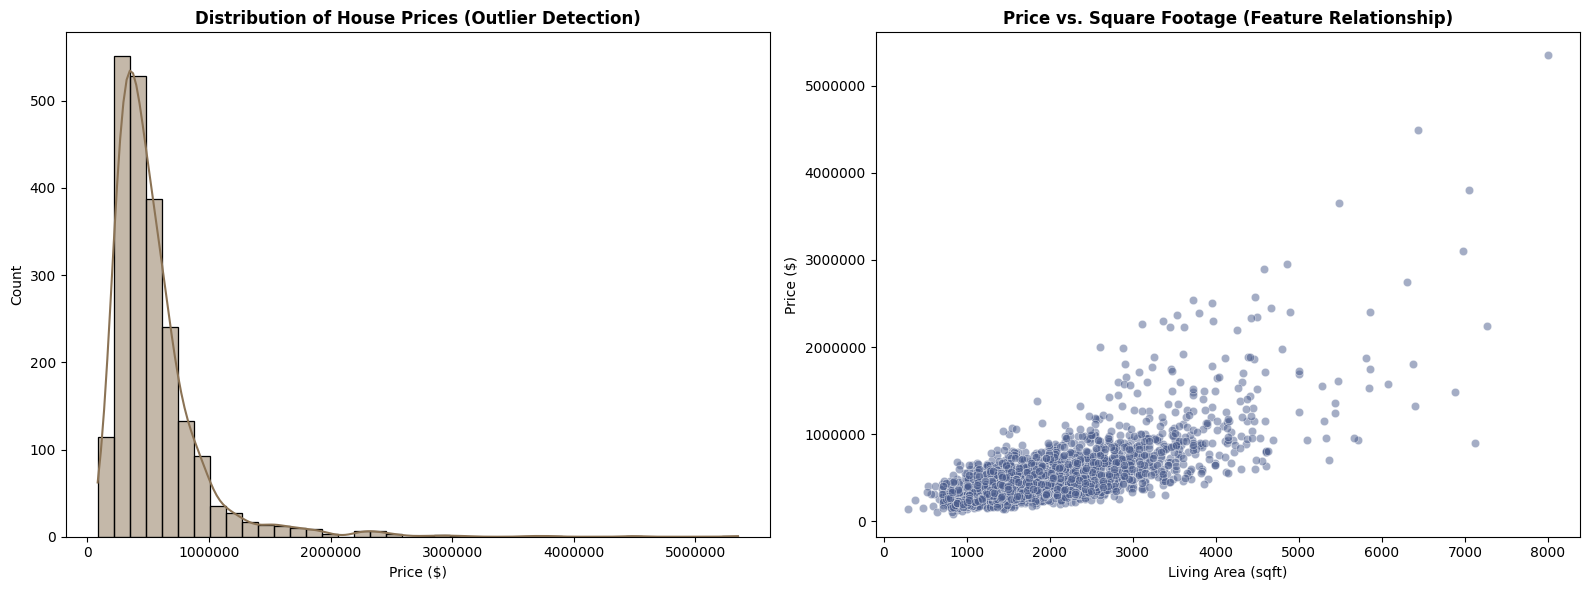

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# 3.1 Statistical Summary of Key Features
print("Statistical Summary (Central Tendency & Spread):")
df.select("price", "bedrooms", "bathrooms", "sqft_living", "condition").describe().show()

# 3.2 Visualizing Distributions & Relationships
# Extract a 10% sample for safe, local visualization without driver memory overload
sample_df = df.sample(fraction=0.1, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Price Distribution (Checking for skewness and outliers)
sns.histplot(sample_df['price'], bins=40, kde=True, ax=axes[0], color='#8B7355')
axes[0].set_title('Distribution of House Prices (Outlier Detection)', fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].ticklabel_format(style='plain', axis='x')

# Plot B: Price vs. Square Footage (Testing assumptions of linearity)
sns.scatterplot(x='sqft_living', y='price', data=sample_df, ax=axes[1], alpha=0.5, color='#4A5C8C')
axes[1].set_title('Price vs. Square Footage (Feature Relationship)', fontweight='bold')
axes[1].set_xlabel('Living Area (sqft)')
axes[1].set_ylabel('Price ($)')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

### 4. Data Insights
Following our generalized EDA, we perform specific, targeted aggregations using Spark's native distributed DataFrame API. This allows us to extract actionable insights—such as luxury market sizing, geographic pricing hierarchies, and condition-based valuations—which we then visualize for reporting.

Insight 1: Luxury Capacity Segment
Homes with more than 4 bedrooms: 1,935



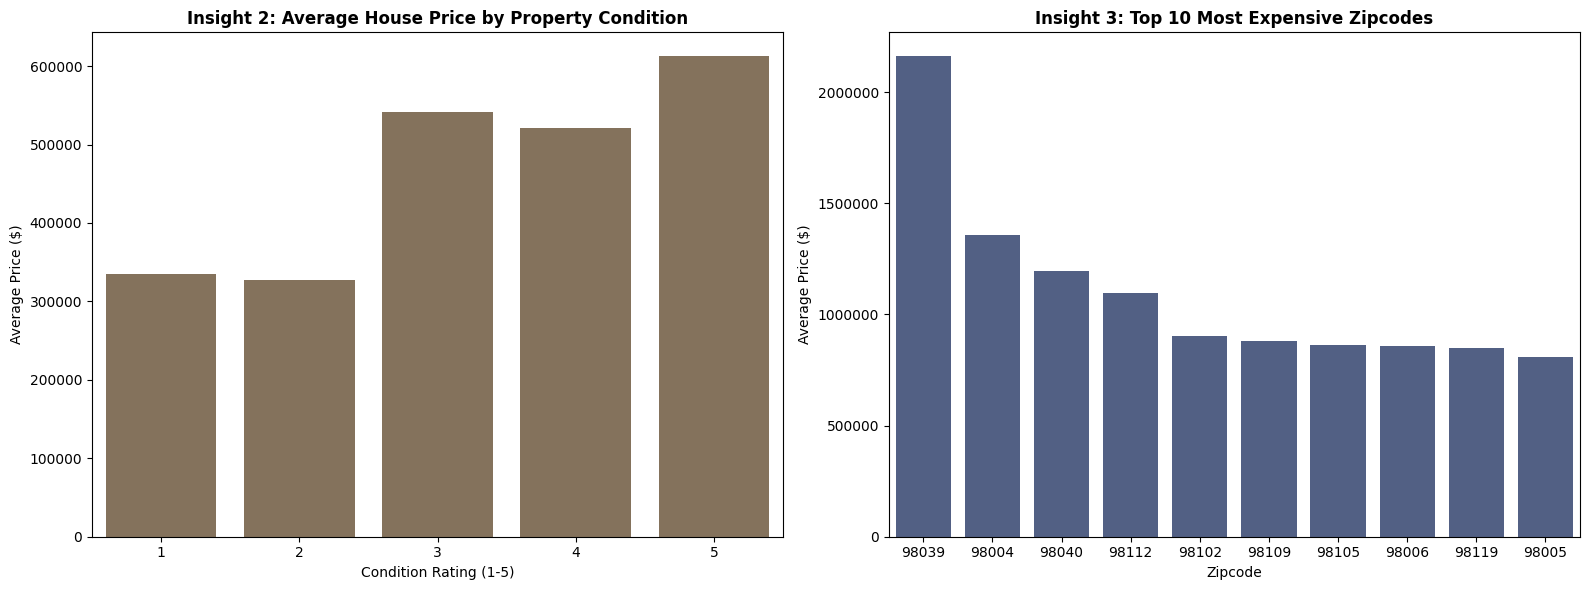

In [ ]:
from pyspark.sql.functions import avg, desc

# Insight 1: Filtering for luxury capacity
print("Insight 1: Luxury Capacity Segment")
large_homes = df.filter(col("bedrooms") > 4).count()
print(f"Homes with more than 4 bedrooms: {large_homes:,}\n")

# Calculate exact aggregations in PySpark, then collect to Pandas for bar charts
condition_df = df.groupBy("condition").agg(avg("price").alias("Avg_Price")).orderBy("condition").toPandas()
zipcode_df = df.groupBy("zipcode").agg(avg("price").alias("Avg_Price")).orderBy(desc("Avg_Price")).limit(10).toPandas()
zipcode_df['zipcode'] = zipcode_df['zipcode'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot C: Average Price by Condition
sns.barplot(x='condition', y='Avg_Price', data=condition_df, ax=axes[0], color='#8B7355')
axes[0].set_title('Insight 2: Average House Price by Property Condition', fontweight='bold')
axes[0].set_xlabel('Condition Rating (1-5)')
axes[0].set_ylabel('Average Price ($)')
axes[0].ticklabel_format(style='plain', axis='y')

# Plot D: Top 10 Zipcodes
sns.barplot(x='zipcode', y='Avg_Price', data=zipcode_df, ax=axes[1], color='#4A5C8C')
axes[1].set_title('Insight 3: Top 10 Most Expensive Zipcodes', fontweight='bold')
axes[1].set_xlabel('Zipcode')
axes[1].set_ylabel('Average Price ($)')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

### 5. Feature Engineering & Spark ML Pipeline
 We calculate a new feature, `house_age`, to give the model better historical context. We also use `StringIndexer` and `OneHotEncoder` to properly handle categorical geographic data (`zipcode`). All features are assembled into a dense vector.

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

# Feature Engineering: Create house_age
df = df.withColumn("house_age", 2015 - col("yr_built"))

# Define Pipeline Stages
indexer = StringIndexer(inputCol="zipcode", outputCol="zipcode_index", handleInvalid="keep")
encoder = OneHotEncoder(inputCol="zipcode_index", outputCol="zipcode_encoded")

# Select explicit features for the model
numeric_cols = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
                "waterfront", "view", "condition", "grade", "house_age", "lat", "long"]

assembler = VectorAssembler(inputCols=numeric_cols + ["zipcode_encoded"], outputCol="features")

# Build and execute the pipeline
pipeline = Pipeline(stages=[indexer, encoder, assembler])
processed_df = pipeline.fit(df).transform(df)

# Split the data (80% Train, 20% Test)
train_data, test_data = processed_df.randomSplit([0.8, 0.2], seed=42)
print(f"Pipeline Complete. Training rows: {train_data.count():,} | Testing rows: {test_data.count():,}")

Pipeline Complete. Training rows: 17,349 | Testing rows: 4,264


### 6.1 Model 1: Linear Regression (Baseline)
**Why we chose it:** To establish a statistical baseline.
**How it works:** Linear regression attempts to model the relationship between the features and the price by fitting a linear equation to observed data. Because real estate pricing relies heavily on non-linear thresholds (e.g., luxury geography), we expect this model to underperform relative to ensemble methods.

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Standardize evaluators for use across all models
evaluator_rmse = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="price", predictionCol="prediction", metricName="r2")

print("Training Linear Regression Baseline...")
lr = LinearRegression(featuresCol="features", labelCol="price")
lr_preds = lr.fit(train_data).transform(test_data)

lr_rmse = evaluator_rmse.evaluate(lr_preds)
lr_r2 = evaluator_r2.evaluate(lr_preds)

print(f"Linear Regression R2: {lr_r2:.4f}")

Training Linear Regression Baseline...
Linear Regression R2: 0.7944


### 6.2 Model 2: Gradient-Boosted Trees (Primary Architecture)
**Why we chose it:** Real estate data contains massive outliers and deep non-linear interactions. GBT is robust to outliers and does not require scaled data.
**How it works:** GBT is an ensemble method that trains decision trees sequentially. Each new tree focuses explicitly on correcting the residual errors made by the previous trees. We initialized this model with `maxIter=50` to provide a strong predictive foundation.

In [ ]:
from pyspark.ml.regression import GBTRegressor

print("Training Baseline GBT (50 Trees)...")
gbt_default = GBTRegressor(featuresCol="features", labelCol="price", maxIter=50)
gbt_default_preds = gbt_default.fit(train_data).transform(test_data)

gbt_default_rmse = evaluator_rmse.evaluate(gbt_default_preds)
gbt_default_r2 = evaluator_r2.evaluate(gbt_default_preds)

print(f"Baseline GBT R2: {gbt_default_r2:.4f}")

Training Baseline GBT (50 Trees)...
Baseline GBT R2: 0.8601


### 6.3 Model 3: GBT with Hyperparameter Tuning
**Why we chose it:** The One-Hot Encoded zipcodes introduce high sparsity to our dataset. Shallow trees often struggle to split effectively on sparse data.
**How it works:** We utilize PySpark's `CrossValidator` to aggressively tune the maximum depth and iteration limits, forcing the algorithm to find deeper geographical patterns that maximize accuracy.

In [ ]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

print("Training Tuned GBT via CrossValidation (This may take a few minutes)...")
gbt_cv = GBTRegressor(featuresCol="features", labelCol="price")

# Define Grid: Test tree depths of 5 vs 7, and 50 vs 75 trees
paramGrid = (ParamGridBuilder() \
             .addGrid(gbt_cv.maxDepth, [5, 7]) \
             .addGrid(gbt_cv.maxIter, [50, 75]) \
             .build())

# 3-Fold CrossValidation
cv = CrossValidator(estimator=gbt_cv,
                    estimatorParamMaps=paramGrid,
                    evaluator=evaluator_rmse,
                    numFolds=3)

tuned_preds = cv.fit(train_data).transform(test_data)

tuned_rmse = evaluator_rmse.evaluate(tuned_preds)
tuned_r2 = evaluator_r2.evaluate(tuned_preds)

print(f"Tuned GBT R2: {tuned_r2:.4f}")

Training Tuned GBT via CrossValidation (This may take a few minutes)...
Tuned GBT R2: 0.8672


### 7. Final Pipeline Performance & Visualizations
We bypass the distributed Spark engine for our final display table and collect our calculated metrics into a local Pandas DataFrame to prevent memory overload. Finally, we visualize the performance lift across our models and graph the predictive spread of our winning Tuned GBT architecture.


             FINAL PIPELINE PERFORMANCE                
   Model Architecture      RMSE ($)  R-Squared (R2)
3. Tuned GBT (Winner) 134661.768335        0.867243
    2. GBT (50 Trees) 138223.887487        0.860127
 1. Linear Regression 167581.965440        0.794400


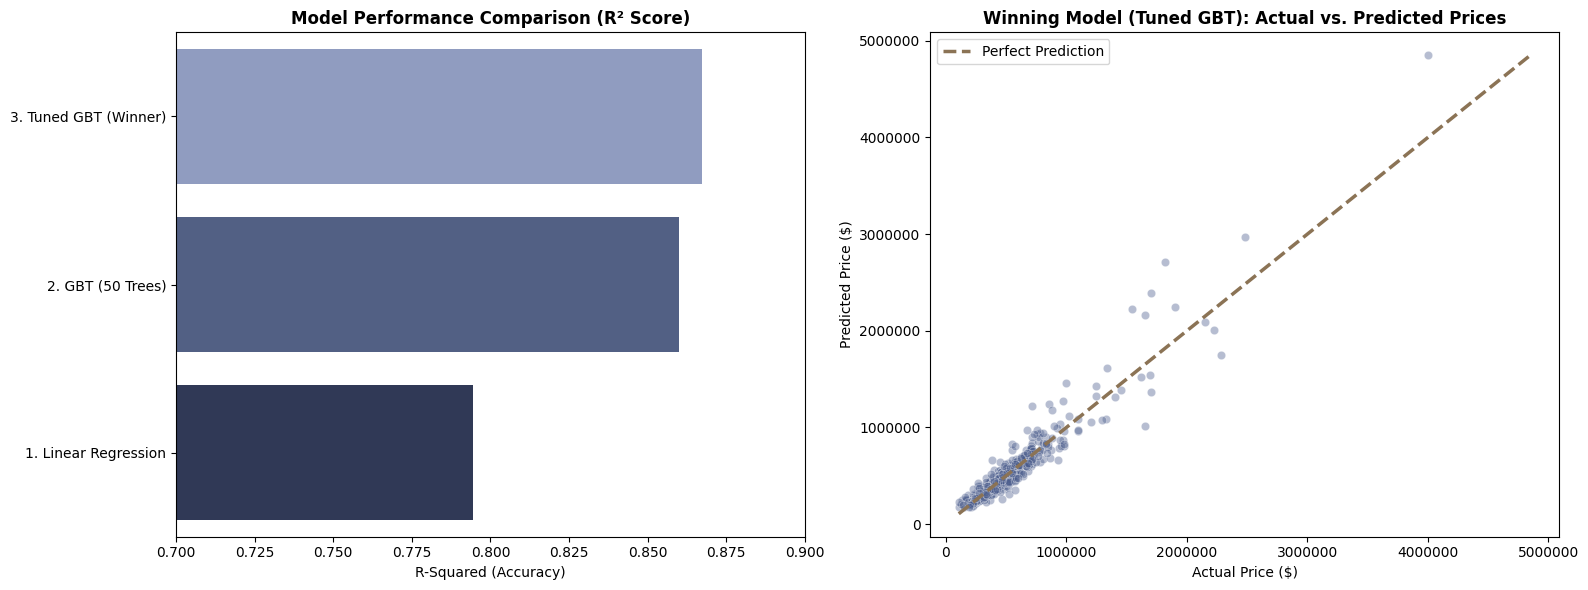

In [ ]:
import pandas as pd

# 1. Create Summary DataFrame
comparison_data = [
    {"Model Architecture": "1. Linear Regression", "RMSE ($)": float(lr_rmse), "R-Squared (R2)": float(lr_r2)},
    {"Model Architecture": "2. GBT (50 Trees)", "RMSE ($)": float(gbt_default_rmse), "R-Squared (R2)": float(gbt_default_r2)},
    {"Model Architecture": "3. Tuned GBT (Winner)", "RMSE ($)": float(tuned_rmse), "R-Squared (R2)": float(tuned_r2)}
]

comparison_df = pd.DataFrame(comparison_data).sort_values(by="RMSE ($)")

print("\n=======================================================")
print("             FINAL PIPELINE PERFORMANCE                ")
print("=======================================================")
print(comparison_df.to_string(index=False))

# 2. Visualize the Final Results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: R2 Score Comparison (Using a gradient of your original blue theme)
sns.barplot(x='R-Squared (R2)', y='Model Architecture', data=comparison_df, ax=axes[0], palette=['#8898C8', '#4A5C8C', '#2A365C'])
axes[0].set_title('Model Performance Comparison (R² Score)', fontweight='bold')
axes[0].set_xlabel('R-Squared (Accuracy)')
axes[0].set_ylabel('')
axes[0].set_xlim(0.70, 0.90)  # Zoom in to highlight the differences

# Plot B: Actual vs Predicted (Best Model)
# Extract 10% sample of predictions for clean plotting
preds_pd = tuned_preds.select("price", "prediction").sample(fraction=0.1, seed=42).toPandas()

sns.scatterplot(x='price', y='prediction', data=preds_pd, ax=axes[1], alpha=0.4, color='#4A5C8C')

# Draw the perfect prediction line
min_val = min(preds_pd['price'].min(), preds_pd['prediction'].min())
max_val = max(preds_pd['price'].max(), preds_pd['prediction'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='#8B7355', linestyle='--', lw=2.5, label='Perfect Prediction')

axes[1].set_title('Winning Model (Tuned GBT): Actual vs. Predicted Prices', fontweight='bold')
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].ticklabel_format(style='plain', axis='both')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Stop the Spark session
spark.stop()